# **<u> Do gun laws and restrictions cause a decrease in gun related deaths per US county?**

In [1]:
# Data Analysis packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics Packages
import scipy.stats as stats
import statsmodels.api as sm

### **Dataset Used:**

https://www.kaggle.com/datasets/ahmedeltom/us-gun-deaths-by-county-19992019

### **Dataset Description:**

The dataset is sourced and edited from
data.world

Description is given as below:

Centers for Disease Control and Prevention, National Center for Health Statistics. Multiple Cause of Death with U.S. - Mexico Border Regions 1999-2019 on CDC WONDER Online Database, released in 2020. Data are from the Multiple Cause of Death Files, 1999-2019, as compiled from data provided by the 57 vital statistics jurisdictions through the Vital Statistics Cooperative Program. U.S. - Mexico border counties has been demarcated as the 44 counties that are located within 100 kilometers (62 miles) defined under the 1983 La Paz Agreement. Accessed at http://wonder.cdc.gov/ucd-border.html on Nov 6, 2021 12:22:30 AM

Query Parameters: Title: Gun Deaths by County MCD - ICD-10 Codes: W32 (Handgun discharge); W33 (Rifle, shotgun and larger firearm discharge); W34 (Discharge from other and unspecified firearms); X72 (Intentional self-harm by handgun discharge); X73 (Intentional self-harm by rifle, shotgun and larger firearm discharge); X74 (Intentional self-harm by other and unspecified firearm discharge); X93 (Assault by handgun discharge); X94 (Assault by rifle, shotgun and larger firearm discharge); X95 (Assault by other and unspecified firearm discharge); Y22 (Handgun discharge, undetermined intent); Y23 (Rifle, shotgun and larger firearm discharge, undetermined intent); Y24 (Other and unspecified firearm discharge, undetermined intent); Y35.0 (Legal intervention involving firearm discharge)

Group By: Year; County Show Totals: True Show Zero Values: False Show Suppressed: False Standard Population: 2000 U.S. Std. Population Calculate Rates Per: 100,000 Rate Options: Default intercensal populations for years 2001-2009 (except Infant Age Groups)

picture sourced from peterplit

### **Innitial Assumption:**
- Do gun laws and restrictions cause a decrease in gun related deaths per US county?

### **Linear Regression for Causal Inferrence:**

> $y$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_{it}$

$y$ = The outcome variable. The dependent variable.

$\beta_0$ = The outcome of the control group.

$\beta_1$ = The average difference in the change of the outcome between the treated and controlled groups.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- Number of Gun Related Deaths

### **Treatment Variable:**
- Strict gun laws, where 1 = state with highly restrictive gun laws, and 0 = state with no or very little gun laws.
- The Gifford Grade is a ratting system used to rates states based on their enacted gun laws. It uses a scale similar to grades in school, where A+ is the highest and then A, A-, B+, B, B-, C+, C, C-, D+, D, D-, and finally F which is the lowest.
- As of 2025, the highest ratesd states with the most restrictive gun laws are:

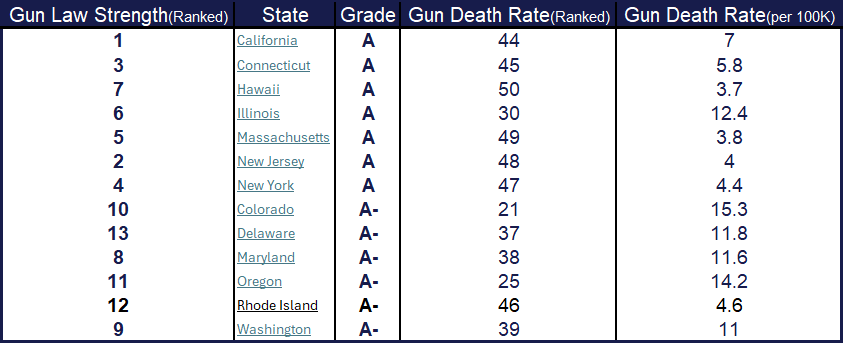

- These states will be the treated in the analysis; the data in the dataframe is by county, so the treated counties are the ones in these states.
- However, the data also goes by year, and these states have enacted their strict gun laws all at different times. So we must account for that.
- According to ChatGPT.com, when inputting these states and asking it to grab data on the years they passed strict gun laws, it outputs this: 

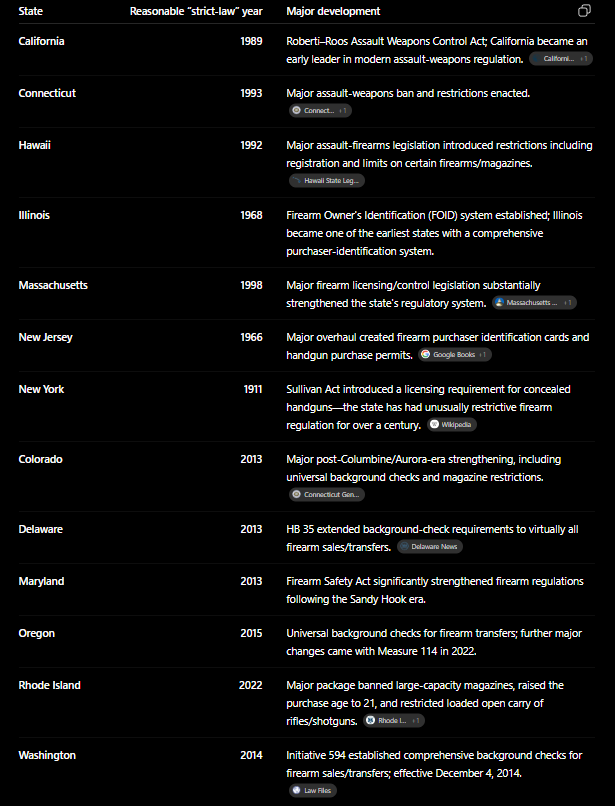

- The dataset includes gun deaths per county per state by years between 1999 and 2019.
- This means some states meant to be treated will be treated starting at their years of treatment.
- The state of Delaware did not pass strict gun laws until 2013, so from 1999 to 2012, Delaware was not treated. But from 2013 to 2019, the state of Delaware is in fact treated.

https://giffords.org/lawcenter/resources/scorecard/?scorecard=CA - Giffords.org

https://worldpopulationreview.com/state-rankings/strictest-gun-laws-by-state - World Population Review.

### **Possible Cofounders:**
- Year, from 1999 to 2013.
- Population of each county.
- County of states. k-1 Dummy Variable.
- States of the United States of America. k-1 Dummy Variable.

### **Linear Regression Equation for Problem:**
> Gun Related Deaths = $\beta_0$ + $\beta_1$ (Restrictive gun laws, 1 = state/county with strict gun laws, 0 = state/county with no or very little strict gun laws) + $\beta_2$ (Year) + $\beta_3$ (County Population) + $\beta_{k-1}$ (k-1 County) + $\beta_{k-1}$ (k - 1 State) + $\epsilon_i$

---

## **Loading and Cleaning Data:**

In [2]:
df = pd.read_csv("C:\BROCK U COURSE DOCS\DataSets\gun_deaths_us_1999_2019.csv")
df

,Unnamed: 0,Year,County,County Code,State,State_Name,State Code,Deaths,Population,Crude Rate,Crude Rate Lower 95% Confidence Interval,Crude Rate Upper 95% Confidence Interval,Age Adjusted Rate,Age Adjusted Rate Lower 95% Confidence Interval,Age Adjusted Rate Upper 95% Confidence Interval
0,0,1999,Baldwin County,1003,AL,Alabama,1,22,137555,15.99,10.02,24.21,16.28,10.20,24.64
1,1,1999,Calhoun County,1015,AL,Alabama,1,29,114910,25.24,16.90,36.24,25.21,16.89,36.21
2,2,1999,Chambers County,1017,AL,Alabama,1,10,36527,NaN,13.13,50.35,NaN,12.91,49.51
3,3,1999,Colbert County,1033,AL,Alabama,1,14,54715,NaN,13.99,42.93,NaN,13.54,41.57
4,4,1999,Dallas County,1047,AL,Alabama,1,11,46722,NaN,11.75,42.13,NaN,12.15,43.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14353,14353,2017,Burleigh County,38015,ND,North Dakota,38,14,95030,NaN,8.05,24.72,NaN,7.15,22.96
14354,14354,2017,Cass County,38017,ND,North Dakota,38,16,177787,NaN,5.14,14.61,NaN,5.14,15.15
14355,14355,2018,Cass County,38017,ND,North Dakota,38,20,181516,11.02,6.73,17.02,10.75,6.47,16.78
14356,14356,2018,Grand Forks County,38035,ND,North Dakota,38,11,70770,NaN,7.76,27.81,NaN,8.48,32.52


In [3]:
df.duplicated().sum()

np.int64(0)

> No duplicated rows exist.

In [4]:
df.isna().sum()

Unnamed: 0                                            0
Year                                                  0
County                                                0
County Code                                           0
State                                                 0
State_Name                                            0
State Code                                            0
Deaths                                                0
Population                                            0
Crude Rate                                         7487
Crude Rate Lower 95% Confidence Interval              0
Crude Rate Upper 95% Confidence Interval              0
Age Adjusted Rate                                  7487
Age Adjusted Rate Lower 95% Confidence Interval       0
Age Adjusted Rate Upper 95% Confidence Interval       0
dtype: int64

> No NaN values exist in any columns that will be used in the analysis.

In [5]:
df.columns

Index(['Unnamed: 0', 'Year', 'County', 'County Code', 'State', 'State_Name',
       'State Code', 'Deaths', 'Population', 'Crude Rate',
       'Crude Rate Lower 95% Confidence Interval',
       'Crude Rate Upper 95% Confidence Interval', 'Age Adjusted Rate',
       'Age Adjusted Rate Lower 95% Confidence Interval',
       'Age Adjusted Rate Upper 95% Confidence Interval'],
      dtype='object')

In [6]:
df = df.drop(labels= ['Unnamed: 0', 'County Code', 'State', 'State Code', 'Crude Rate', 
                      'Crude Rate Lower 95% Confidence Interval', 'Crude Rate Upper 95% Confidence Interval', 
                      'Age Adjusted Rate', 'Age Adjusted Rate Lower 95% Confidence Interval', 
                      'Age Adjusted Rate Upper 95% Confidence Interval'], axis= 1)

df

,Year,County,State_Name,Deaths,Population
0,1999,Baldwin County,Alabama,22,137555
1,1999,Calhoun County,Alabama,29,114910
2,1999,Chambers County,Alabama,10,36527
3,1999,Colbert County,Alabama,14,54715
4,1999,Dallas County,Alabama,11,46722
...,...,...,...,...,...
14353,2017,Burleigh County,North Dakota,14,95030
14354,2017,Cass County,North Dakota,16,177787
14355,2018,Cass County,North Dakota,20,181516
14356,2018,Grand Forks County,North Dakota,11,70770


> We removed unnecessary columns in the dataset.

In [7]:
df['Strict_Laws'] = (
    (df['State_Name'] == 'California') |
    (df['State_Name'] == 'Connecticut') |
    (df['State_Name'] == 'Hawaii') |
    (df['State_Name'] == 'Illinois') |
    (df['State_Name'] == 'Massachusetts') |
    (df['State_Name'] == 'New Jersey') |
    (df['State_Name'] == 'New York') | 
    ((df['State_Name'] == 'Colorado') & (df['Year'] >= 2013)) |
    ((df['State_Name'] == 'Delaware') & (df['Year'] >= 2013)) |
    ((df['State_Name'] == 'Maryland') & (df['Year'] >= 2013)) |
    ((df['State_Name'] == 'Oregon') & (df['Year'] >= 2015)) |
    ((df['State_Name'] == 'Washington') & (df['Year'] >= 2014))
).astype(int)


> We added the treatment variable, where 1 = states with strict gun laws, and 0 = states with not strict gun laws. NOTE: The state of Rhode Island is not treated because their strict gun laws came into affect in 2022, well beyond the 20 year timeframe of 1999 to 2019.

In [8]:
counties = pd.get_dummies(df['County'], drop_first= True).astype(int)

df = df.drop(labels= 'County', axis= 1)

df = pd.merge(df, counties, left_index= True, right_index= True)
df

,Year,State_Name,Deaths,Population,Strict_Laws,Acadia Parish,Accomack County,Ada County,Adams County,Aiken County,...,Yakima County,Yamhill County,Yavapai County,Yazoo County,Yellowstone County,Yolo County,York County,Yuba County,Yukon-Koyukuk Census Area,Yuma County
0,1999,Alabama,22,137555,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1999,Alabama,29,114910,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1999,Alabama,10,36527,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1999,Alabama,14,54715,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1999,Alabama,11,46722,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14353,2017,North Dakota,14,95030,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14354,2017,North Dakota,16,177787,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14355,2018,North Dakota,20,181516,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14356,2018,North Dakota,11,70770,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


> Added the county dummy variables, minus one of the county columns. Also dropped the County column.

In [9]:
states = pd.get_dummies(df['State_Name'], drop_first= True).astype(int)

df = df.drop(labels= 'State_Name', axis= 1)

df = pd.merge(df, states, left_index= True, right_index= True)
df

,Year,Deaths,Population,Strict_Laws,Acadia Parish,Accomack County,Ada County,Adams County,Aiken County,Alachua County,...,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming
0,1999,22,137555,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1999,29,114910,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1999,10,36527,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1999,14,54715,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1999,11,46722,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14353,2017,14,95030,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14354,2017,16,177787,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14355,2018,20,181516,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14356,2018,11,70770,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


> Added the state dummy variables, minus one of the states. Also dropped the State_Name column.

## **Creating Model for Causal Effect Analysis:**

In [10]:
y = df['Deaths']

df = df.drop(labels= 'Deaths', axis= 1)
x = df
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     194.1
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:31:44   Log-Likelihood:                -61359.
No. Observations:               14358   AIC:                         1.246e+05
Df Residuals:                   13398   BIC:                         1.319e+05
Df Model:                         959                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                         -408.6092     55.374     -7.379      0.000    -517.150    -300.069
Year                             0.2075      0.026      7.956      0.000       0.156       0.259
Population                       0.0001   9.46e-07    111.031      0.000       0.000       0.000
Strict_Laws                      2.3415      1.180      1.984      0.047       0.029       4.654
Acadia Parish                   -7.4339      5.071     -1.466      0.143     -17.374       2.506
Accomack County                  5.4666     25.600      0.214      0.831     -44.712      55.645
Ada County                      -5.2918      4.608     -1.148      0.251     -14.324       3.741
Adams County                     4.2451     18.380      0.231      0.817     -31.782      40.272
Aiken County                     2.4226     18.402      0.132      0.895     -33.648      38.493
Alachua County                 -11.8309     18.560     -0.637      0.524     -48.212      24.550
Alamance County                  2.5498     18.606      0.137      0.891     -33.920      39.020
Alameda County                  56.1660     18.786      2.990      0.003      19.343      92.989
Albany County                   26.7811     18.653      1.436      0.151      -9.781      63.343
Albemarle County                -1.0289     19.301     -0.053      0.957     -38.861      36.804
Alcorn County                    2.5954     20.265      0.128      0.898     -37.128      42.318
Alexander County                 9.0081     22.152      0.407      0.684     -34.414      52.430
Alexandria city                 -4.9631     19.647     -0.253      0.801     -43.473      33.547
Allegan County                 -27.0642     19.427     -1.393      0.164     -65.145      11.016
Allegany County                 27.4313     21.011      1.306      0.192     -13.754      68.617
Allegheny County                29.4974     18.565      1.589      0.112      -6.892      65.887
Allen County                    -2.6905     18.419     -0.146      0.884     -38.794      33.413
Amador County                   74.7696     22.355      3.345      0.001      30.950     118.589
Amherst County                   8.4981     25.599      0.332      0.740     -41.680      58.676
Anchorage Borough                6.8014      5.377      1.265      0.206      -3.739      17.342
Anderson County                  1.4003     18.224      0.077      0.939     -34.321      37.122
Androscoggin County              9.0089     19.526      0.461      0.645     -29.264      47.282
Angelina County                  1.2858     18.657      0.069      0.945     -35.284      37.856
Anne Arundel County             11.6990     18.681      0.626      0.531     -24.919      48.317
Anoka County                     3.7788     18.863      0.200      0.841    

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> Gun Related Deaths = -408.6092 + 2.3415 (Restrictive gun laws, 1 = state/county with strict gun laws, 0 = state/county with no or very little strict gun laws) + 0.2075 (Year) + 0.0001 (County Population) + $\beta_{k-1}$ (k-1 County) + $\beta_{k-1}$ (k - 1 State) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: Population average difference in the outcome between counties of states with strict gun laws (treated = 1) and counties of states not strict gun laws (controlled = 0) $\beta_1$ = 0

Ha: Population average difference in the outcome between counties of states with strict gun laws (treated = 1) and counties of states not strict gun laws (controlled = 0) $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE[$\beta_1$]

t-stat = (2.3415 - 0) / 1.180

t-stat = 1.984

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.047

$\alpha$ = 0.05

=> p-value < $\alpha$

=> 0.047 < 0.05

=> We reject the null hypothesis; Population average difference in the outcome between counties of states with strict gun laws (treated = 1) and counties of states not strict gun laws (controlled = 0) $\beta_1$ != 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_1$ - (t[0.05] * SE), $\beta_1$ + (t[0.05] * SE)]

Confidence Interval = [2.3415 - (1.96 * 1.180), 2.3415 + (1.96 * 1.180)]

Confidence Interval = [0.029, 4.654]

=> Confidence interval does not contain zero and therefore these results confirm the hypothesis test that $\beta_1$ != 0.

### **Description, Reasoning, and Summary:**
- The model does not confirm the relationship proposed in the initial assumption, which said that states with strict gun laws will see a decrease in gun related deaths per county.
- This is however not the case, and the opposite is seen. The model shows that states with strict gun laws will have an average of 2.3415 more gun related deaths per county than those states with no or very little gun restrictions. This is while controlling for year, population, state, and county.
- This relationship is also statistically significant by only 0.003.
- The difference between the sample $\beta_1$ and zero, given the standard deviation, is high, which tells us that the sample $\beta_1$ is not zero.
- Since this is the case, the probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true is low.
- This is because we assume the null hypothesis is true, and that population $\beta_1$ is equal to zero. However, the sample $\beta_1$ does not confirm this to be true.
- The sample $\beta_1$ is not zero, and it does not confirm the truth of the null hypothesis. The null hypothesis of the population $\beta_1$ does not accuratly represent the sample data.
- Therefore the null hypothesis is rejected for the alternative. The population average difference in the outcome between counties of states with strict gun laws (treated = 1) and counties of states not strict gun laws (controlled = 0) $\beta_1$ != 0.
- But, statistical significance does not automatically mean the relationship is causal.
- The sample data is not collected at random since it is displaying what actually occured to the total populations of each state county. This is not a big issue, the issue is the treatment variable.
- Treatment is not assigned randomly since states choose to restrict their gun laws due to the freedom granted by the second amendment of the American constitution.
- Since the treatment is not random, we must then control for all possible significant cofounders; variables that affect both the outcome and treatment.
- Hovever, this is practically impossible. The only cofounders we have in the dataframe are states, counties, populations, and year.
- We do not have variables for other possible cofounders that may affect gun deaths per county and state legislation.
- Some of these cofounders may include crime rate (for gange violence), depression or mental health rates (for scuicides by guns), education, income, etc.
- Since we are not controlling for ALL possible cofounders, we cannot possibly confirm with certainty that this relationship is causal.
- We can only assume this relationship may be causal if no other significant cofounder exists. A way to do this is to use a difference-in-difference design to come up with a infer causality. 

---